# Análise Exploratória do Spotify

A ideia é criar um dashboard mostrando estatísticas das músicas de um determinado músico/grupo.

In [1]:
import spotipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from spotipy.oauth2 import SpotifyClientCredentials
import json

%matplotlib inline

In [23]:
cred = json.load(open('auth.json'))
client_id = cred['client_id']
client_secret = cred['client_secret']
ccm = SpotifyClientCredentials(client_id=client_id,client_secret=client_secret)
sp = spotipy.Spotify(client_credentials_manager=ccm)

In [24]:
uri = 'spotify:artist:1b8kpp4DUwt1hWaxTiWQhD'

results = sp.artist_albums(uri, album_type='album')
albums = results['items']
while results['next']:
    results = sp.next(results)
    albums.extend(results['items'])

for album in albums:
    print(album['name'])

Nenhuma Dor
A Pele do Futuro Ao Vivo
A Pele do Futuro
Trinca de Ases (Ao Vivo)
Estratosférica Ao Vivo
Gal Estratosférica
A Arte De Gal Costa
Recanto Ao Vivo
Recanto
Divina, Maravilhosa
Live at the Blue Note
Gal Costa (Ao Vivo)
Hoje
Divino Maravilhoso - Gal Costa Interpreta Caetano Veloso (CD 2)
Divino Maravilhoso - Gal Costa Interpreta Caetano Veloso (CD 1)
Gal Canta Caetano
O Amor
Todas as coisas e eu
Gal Bossa Tropical
Duetos
Gal De Tantos Amores
Gal Costa Sem Limite
Minha Voz, Minha Vida
T.S.O. Do Filme Gabriela
Gal Costa Canta Tom Jobim
Aquele Frevo Axé
Obras-Primas
Mina D'Água do Meu Canto
O Sorriso Do Gato De Alice
Plural
Rio Revisited
Profana
Baby Gal
Minha Voz
Fantasia
Aquarela Do Brasil
Gal Tropical
Agua Viva
Caras E Bocas
Gal Canta Caymmi
Temporada De Verao
Cantar
India
Live In London '71, Vol. 2 (Ao Vivo)
Live In London '71, Vol. 1 (Ao Vivo)
Gal A Todo Vapor (Live)
Legal
Gal Costa
Gal Costa
Domingo


In [8]:
for album in albums:
    print(album.keys())
print(albums[0])

dict_keys(['album_type', 'total_tracks', 'available_markets', 'external_urls', 'href', 'id', 'images', 'name', 'release_date', 'release_date_precision', 'type', 'uri', 'artists', 'album_group'])
dict_keys(['album_type', 'total_tracks', 'available_markets', 'external_urls', 'href', 'id', 'images', 'name', 'release_date', 'release_date_precision', 'type', 'uri', 'artists', 'album_group'])
dict_keys(['album_type', 'total_tracks', 'available_markets', 'external_urls', 'href', 'id', 'images', 'name', 'release_date', 'release_date_precision', 'type', 'uri', 'artists', 'album_group'])
dict_keys(['album_type', 'total_tracks', 'available_markets', 'external_urls', 'href', 'id', 'images', 'name', 'release_date', 'release_date_precision', 'type', 'uri', 'artists', 'album_group'])
dict_keys(['album_type', 'total_tracks', 'available_markets', 'external_urls', 'href', 'id', 'images', 'name', 'release_date', 'release_date_precision', 'type', 'uri', 'artists', 'album_group'])
dict_keys(['album_type', 

In [25]:
df = []
for album in albums:
    df.append([album['name'], album['release_date'][:4], album['total_tracks']])
df = pd.DataFrame(df, columns=['name', 'release_year', 'total_tracks'])
df.head()

,name,release_year,total_tracks
0,Nenhuma Dor,2021,10
1,A Pele do Futuro Ao Vivo,2019,21
2,A Pele do Futuro,2018,13
3,Trinca de Ases (Ao Vivo),2018,25
4,Estratosférica Ao Vivo,2017,22


In [26]:
grouped = df.groupby('release_year').name.count()
grouped.head(10)

release_year
1967    1
1969    2
1970    1
1971    3
1973    1
1974    2
1976    1
1977    1
1978    1
1979    1
Name: name, dtype: int64

<Axes: xlabel='release_year'>

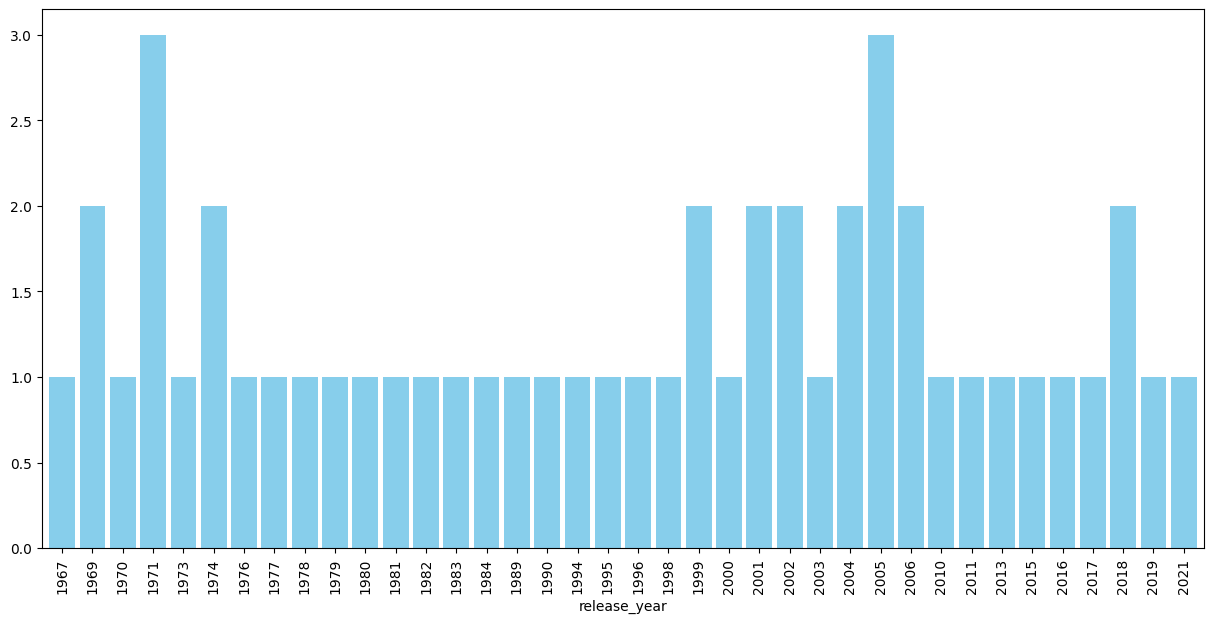

In [31]:
grouped.plot(kind='bar', figsize=(15, 7), color='skyblue', zorder=2, width=0.85)